# 🔬 Impact de l'ACP sur la précision des descripteurs CNN

Analyse complète de l'impact de la réduction par ACP sur :
- **Recall@K** (K = 1, 5, 10)
- **mAP** (mean Average Precision)
- **Compression mémoire** gagnée

**Modèles analysés :**
- ResNet (zero-shot)
- ViT-Base (zero-shot)
- DinoV2 (zero-shot)
- DinoV2 (SuperCon)
- MobileNetV2 (zero-shot)
- MobileNetV2 (ArcFace)


---
## ⚙️ Configuration — À COMPLÉTER

> **⚠️ IMPORTANT** : Remplis les chemins ci-dessous avant d'exécuter le notebook.

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# ==============================================================
# 📁  CHEMINS À COMPLÉTER — modifie ces variables
# ==============================================================

MODEL_PATHS = {
    "ResNet_ZeroShot":      "/content/drive/MyDrive/MIR_Project/indexes/resnet50_zeroshot.npz",   # ← à compléter
    "ViTBase_ZeroShot":     "/content/drive/MyDrive/MIR_Project/indexes/vit_b16_zeroshot.npz",  # ← à compléter
    "DinoV2_ZeroShot":      "/content/drive/MyDrive/MIR_Project/indexes/dinov2_zeroshot.npz",   # ← à compléter
    "DinoV2_SuperCon":      "/content/drive/MyDrive/MIR_Project/indexes/dinov2_supcon.npz",   # ← à compléter
    "MobileNetV2_ZeroShot": "/content/drive/MyDrive/MIR_Project/indexes/mobilenet_zeroshot.npz",# ← à compléter
    "MobileNetV2_ArcFace":  "/content/drive/MyDrive/MIR_Project/indexes/mobilenet_arcface.npz", # ← à compléter
}

# Chemin vers les labels (classes/indices pour calculer Recall et mAP)
# Format attendu : tableau numpy 1D d'entiers (un label par image, même ordre que les descripteurs)
LABELS_PATH = "/content/drive/MyDrive/MIR_Project/indexes/classes.npy"  # ← à compléter
SAVE_DIR     = "/content/drive/MyDrive/MIR_Project/ACP_Analysis"

# ==============================================================
# ⚙️  Paramètres de l'analyse
# ==============================================================

# Dimensions testées lors de la réduction ACP
# Mets None pour tester automatiquement de 8 jusqu'à la dim originale
PCA_DIMS_OVERRIDE = None  # ex: [32, 64, 128, 256, 512] pour forcer des valeurs spécifiques

# Valeurs de K pour le Recall@K
RECALL_K_VALUES = [1, 5, 10]

# Nombre de voisins pour la recherche (doit être >= max(RECALL_K_VALUES))
N_NEIGHBORS = 10

# Fraction du dataset utilisée comme requêtes (le reste = galerie)
# 0.2 => 20% requêtes, 80% galerie
QUERY_FRACTION = 0.2

# Graine aléatoire pour la reproductibilité
RANDOM_SEED = 42

print("✅ Configuration chargée.")
print(f"   Modèles configurés : {list(MODEL_PATHS.keys())}")
print(f"   Recall@K calculé pour K = {RECALL_K_VALUES}")
print(f"   Split requêtes/galerie : {int(QUERY_FRACTION*100)}% / {int((1-QUERY_FRACTION)*100)}%")

✅ Configuration chargée.
   Modèles configurés : ['ResNet_ZeroShot', 'ViTBase_ZeroShot', 'DinoV2_ZeroShot', 'DinoV2_SuperCon', 'MobileNetV2_ZeroShot', 'MobileNetV2_ArcFace']
   Recall@K calculé pour K = [1, 5, 10]
   Split requêtes/galerie : 20% / 80%


---
## 📦 Imports & Installation des dépendances

In [15]:
# Installation si nécessaire (Colab / environnement frais)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import faiss
except ImportError:
    print("Installation de faiss-cpu...")
    install("faiss-cpu")

try:
    import plotly
except ImportError:
    install("plotly")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
import faiss
from tqdm.auto import tqdm
import os
import json

# Style matplotlib propre
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#e6edf3",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#e6edf3",
    "grid.color":        "#21262d",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "lines.linewidth":   2,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Palette de couleurs — une par modèle
MODEL_COLORS = {
    "ResNet_ZeroShot":      "#58a6ff",
    "ViTBase_ZeroShot":     "#bc8cff",
    "DinoV2_ZeroShot":      "#3fb950",
    "DinoV2_SuperCon":      "#79c0ff",
    "MobileNetV2_ZeroShot": "#ffa657",
    "MobileNetV2_ArcFace":  "#ff7b72",
}

print("✅ Imports OK.")

✅ Imports OK.


---
## 🛠️ Fonctions utilitaires

In [16]:
def load_descriptors(path):
    """Charge un fichier de descripteurs .npy ou .npz"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable : {path}")
    if path.endswith(".npz"):
        data = np.load(path)
        # Essaie les clés classiques
        for key in ["descriptors", "features", "embeddings", "arr_0"]:
            if key in data:
                return data[key].astype(np.float32)
        return data[list(data.keys())[0]].astype(np.float32)
    return np.load(path).astype(np.float32)


def compute_recall_at_k(query_labels, gallery_labels, indices, k):
    """
    Recall@K : fraction de requêtes pour lesquelles au moins 1 des K
    voisins les plus proches appartient à la même classe.
    (On exclut la requête elle-même si elle est dans la galerie)
    """
    hits = 0
    for i, (q_label, nn_idxs) in enumerate(zip(query_labels, indices)):
        nn_labels = gallery_labels[nn_idxs[:k]]
        if q_label in nn_labels:
            hits += 1
    return hits / len(query_labels)


def compute_map(query_labels, gallery_labels, indices):
    """
    mAP : mean Average Precision sur tous les K voisins récupérés.
    AP(q) = (1/R_q) * sum_k [rel(k) * P@k]
    où R_q = nombre total de positifs dans la galerie pour la requête q.
    """
    aps = []
    for q_label, nn_idxs in zip(query_labels, indices):
        nn_labels = gallery_labels[nn_idxs]
        relevant = (nn_labels == q_label).astype(float)
        total_relevant = int((gallery_labels == q_label).sum())
        if total_relevant == 0:
            continue
        cumsum = np.cumsum(relevant)
        positions = np.arange(1, len(nn_idxs) + 1)
        precisions = cumsum / positions
        ap = np.sum(precisions * relevant) / total_relevant
        aps.append(ap)
    return float(np.mean(aps)) if aps else 0.0


def evaluate_descriptors(feats, labels, n_neighbors=10, recall_ks=[1, 5, 10],
                          query_fraction=0.2, seed=42):
    """
    Évalue Recall@K et mAP sur un jeu de descripteurs.
    Split query/gallery, recherche FAISS flat L2 après L2-normalisation.
    """
    idx = np.arange(len(feats))
    q_idx, g_idx = train_test_split(idx, test_size=1 - query_fraction,
                                     random_state=seed, stratify=labels)
    q_feats  = normalize(feats[q_idx],  norm="l2").astype(np.float32)
    g_feats  = normalize(feats[g_idx],  norm="l2").astype(np.float32)
    q_labels = labels[q_idx]
    g_labels = labels[g_idx]

    dim = g_feats.shape[1]
    index = faiss.IndexFlatIP(dim)  # produit scalaire sur vecteurs L2-normalisés == cosinus
    index.add(g_feats)
    _, nn_indices = index.search(q_feats, n_neighbors)

    results = {}
    for k in recall_ks:
        results[f"Recall@{k}"] = compute_recall_at_k(q_labels, g_labels, nn_indices, k)
    results["mAP"] = compute_map(q_labels, g_labels, nn_indices)
    return results


def apply_pca_whitening(feats_train, feats_all, n_components, eps=1e-3):
    """
    Applique ACP + whitening avec régularisation epsilon.
    Le PCA est fitté sur feats_train uniquement (pas de fuite).
    Retourne les descripteurs réduits pour tout le dataset.
    """
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(feats_train)

    feats_proj  = pca.transform(feats_all)
    std_devs    = np.sqrt(pca.explained_variance_) + eps
    feats_white = feats_proj / std_devs
    return feats_white.astype(np.float32)


def memory_mb(feats):
    """Taille mémoire d'un tableau numpy en MB"""
    return feats.nbytes / (1024 ** 2)


print("✅ Fonctions utilitaires définies.")

✅ Fonctions utilitaires définies.


---
## 📂 Chargement des descripteurs

In [19]:
all_descriptors = {}
labels = None

# Chargement des labels
print("Chargement des labels...")
labels = np.load(LABELS_PATH)
print(f"  Labels : {labels.shape[0]} images, {len(np.unique(labels))} classes uniques")

# Chargement de chaque modèle
print("\nChargement des descripteurs :")
for name, path in MODEL_PATHS.items():
    try:
        desc = load_descriptors(path)
        all_descriptors[name] = desc
        print(f"  ✅ {name:<28} — shape: {desc.shape}, dtype: {desc.dtype}, "
              f"RAM: {memory_mb(desc):.1f} MB")
    except FileNotFoundError as e:
        print(f"  ❌ {name:<28} — {e}")

loaded_models = list(all_descriptors.keys())
print(f"\n{len(loaded_models)}/{len(MODEL_PATHS)} modèles chargés avec succès.")

Chargement des labels...
  Labels : 5012 images, 46 classes uniques

Chargement des descripteurs :
  ✅ ResNet_ZeroShot              — shape: (5012, 2048), dtype: float32, RAM: 39.2 MB
  ✅ ViTBase_ZeroShot             — shape: (5012, 768), dtype: float32, RAM: 14.7 MB
  ✅ DinoV2_ZeroShot              — shape: (5012, 256), dtype: float32, RAM: 4.9 MB
  ✅ DinoV2_SuperCon              — shape: (5012, 256), dtype: float32, RAM: 4.9 MB
  ✅ MobileNetV2_ZeroShot         — shape: (5012, 1280), dtype: float32, RAM: 24.5 MB
  ✅ MobileNetV2_ArcFace          — shape: (5012, 256), dtype: float32, RAM: 4.9 MB

6/6 modèles chargés avec succès.


---
## 📊 Analyse ACP par modèle

Pour chaque modèle :
1. Calcul de la **variance expliquée cumulée** → identification du coude
2. Évaluation des métriques (Recall@K, mAP) à chaque dimension ACP
3. Calcul du **gain mémoire**

In [27]:
import json
# Dimensions ACP à tester pour chaque modèle
def get_pca_dims(original_dim):
    if PCA_DIMS_OVERRIDE is not None:
        return [d for d in PCA_DIMS_OVERRIDE if d < original_dim]
    # Grille logarithmique de 8 jusqu'à original_dim
    dims = sorted(set([
        8, 16, 32, 64, 128, 256, 512, 768, 1024, 2048
    ] + list(np.unique(np.logspace(
        np.log10(8), np.log10(original_dim - 1), num=20, dtype=int
    )))))
    return [d for d in dims if d < original_dim]


all_results = {}  # stocke tout pour les graphes de comparaison

for model_name, feats in all_descriptors.items():
    print(f"\n{'='*60}")
    print(f"  Modèle : {model_name}  (dim={feats.shape[1]})")
    print(f"{'='*60}")

    orig_dim  = feats.shape[1]
    n_samples = feats.shape[0]
    orig_mb   = memory_mb(feats)

    # Split train/eval pour éviter data leakage dans le PCA
    idx_all   = np.arange(n_samples)
    idx_train, idx_eval = train_test_split(idx_all, test_size=0.3,
                                           random_state=RANDOM_SEED,
                                           stratify=labels)
    feats_train = feats[idx_train]

    # ── 1. Variance expliquée cumulée (fit PCA complet une seule fois)
    max_components = min(n_samples, orig_dim) - 1
    pca_full = PCA(n_components=max_components, random_state=42)
    pca_full.fit(feats_train)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)

    # Seuils de variance expliquée
    thresholds = {0.80: None, 0.90: None, 0.95: None, 0.99: None}
    for thresh in thresholds:
        idxs = np.where(cumvar >= thresh)[0]
        thresholds[thresh] = int(idxs[0] + 1) if len(idxs) > 0 else max_components

    print(f"  Composantes nécessaires :")
    for t, d in thresholds.items():
        reduction = (1 - d / orig_dim) * 100
        print(f"    {int(t*100)}% variance → {d:4d} dims  (réduction {reduction:.0f}%)")

    # ── 2. Évaluation baseline (sans ACP)
    print("  Évaluation baseline (dim originale)...")
    baseline_metrics = evaluate_descriptors(
        feats, labels, n_neighbors=N_NEIGHBORS,
        recall_ks=RECALL_K_VALUES, query_fraction=QUERY_FRACTION,
        seed=RANDOM_SEED
    )
    print(f"  Baseline → {baseline_metrics}")

    # ── 3. Évaluation pour chaque dimension ACP
    pca_dims  = get_pca_dims(orig_dim)
    pca_results = []

    for d in tqdm(pca_dims, desc=f"  ACP dims", leave=False):
        reduced = apply_pca_whitening(feats_train, feats, n_components=d)
        m = evaluate_descriptors(
            reduced, labels, n_neighbors=N_NEIGHBORS,
            recall_ks=RECALL_K_VALUES, query_fraction=QUERY_FRACTION,
            seed=RANDOM_SEED
        )
        m["dim"]    = d
        m["mem_mb"] = memory_mb(reduced)
        m["compression"] = (1 - d / orig_dim) * 100
        pca_results.append(m)

    all_results[model_name] = {
        "orig_dim":        orig_dim,
        "orig_mb":         orig_mb,
        "baseline":        baseline_metrics,
        "pca_results":     pca_results,
        "cumvar":          cumvar,
        "thresholds":      thresholds,
        "n_samples":       n_samples,
    }



    print(f"  ✅ {len(pca_results)} configurations évaluées.")

print("\n✅ Analyse terminée pour tous les modèles.")


  Modèle : ResNet_ZeroShot  (dim=2048)
  Composantes nécessaires :
    80% variance →  111 dims  (réduction 95%)
    90% variance →  255 dims  (réduction 88%)
    95% variance →  448 dims  (réduction 78%)
    99% variance →  965 dims  (réduction 53%)
  Évaluation baseline (dim originale)...
  Baseline → {'Recall@1': 0.3522954091816367, 'Recall@5': 0.6117764471057884, 'Recall@10': 0.7365269461077845, 'mAP': 0.014476332784044865}


  ACP dims:   0%|          | 0/29 [00:00<?, ?it/s]

  ✅ 29 configurations évaluées.

  Modèle : ViTBase_ZeroShot  (dim=768)
  Composantes nécessaires :
    80% variance →  108 dims  (réduction 86%)
    90% variance →  231 dims  (réduction 70%)
    95% variance →  359 dims  (réduction 53%)
    99% variance →  593 dims  (réduction 23%)
  Évaluation baseline (dim originale)...
  Baseline → {'Recall@1': 0.4181636726546906, 'Recall@5': 0.6806387225548902, 'Recall@10': 0.779441117764471, 'mAP': 0.0179833049662299}


  ACP dims:   0%|          | 0/26 [00:00<?, ?it/s]

  ✅ 26 configurations évaluées.

  Modèle : DinoV2_ZeroShot  (dim=256)
  Composantes nécessaires :
    80% variance →    7 dims  (réduction 97%)
    90% variance →   10 dims  (réduction 96%)
    95% variance →   13 dims  (réduction 95%)
    99% variance →   34 dims  (réduction 87%)
  Évaluation baseline (dim originale)...
  Baseline → {'Recall@1': 0.7674650698602794, 'Recall@5': 0.9201596806387226, 'Recall@10': 0.9471057884231537, 'mAP': 0.0765037164703325}


...

  ✅ 24 configurations évaluées.

  Modèle : MobileNetV2_ZeroShot  (dim=1280)
  Composantes nécessaires :
    80% variance →  138 dims  (réduction 89%)
    90% variance →  280 dims  (réduction 78%)
    95% variance →  443 dims  (réduction 65%)
    99% variance →  804 dims  (réduction 37%)
  Évaluation baseline (dim originale)...
  Baseline → {'Recall@1': 0.2934131736526946, 'Recall@5': 0.5558882235528942, 'Recall@10': 0.6866267465069861, 'mAP': 0.010090625469151602}


  ACP dims:   0%|          | 0/29 [00:00<?, ?it/s]

  ✅ 29 configurations évaluées.

  Modèle : MobileNetV2_ArcFace  (dim=256)
  Composantes nécessaires :
    80% variance →   31 dims  (réduction 88%)
    90% variance →   40 dims  (réduction 84%)
    95% variance →   49 dims  (réduction 81%)
    99% variance →  167 dims  (réduction 35%)
  Évaluation baseline (dim originale)...
  Baseline → {'Recall@1': 0.5069860279441117, 'Recall@5': 0.7385229540918163, 'Recall@10': 0.8173652694610778, 'mAP': 0.04147510507105878}


  ACP dims:   0%|          | 0/24 [00:00<?, ?it/s]

  ✅ 24 configurations évaluées.

✅ Analyse terminée pour tous les modèles.


---
## 📈 Graphes par modèle

Pour chaque modèle : variance expliquée + Recall@K + mAP + compression mémoire

NameError: name 'SAVE_DIR' is not defined

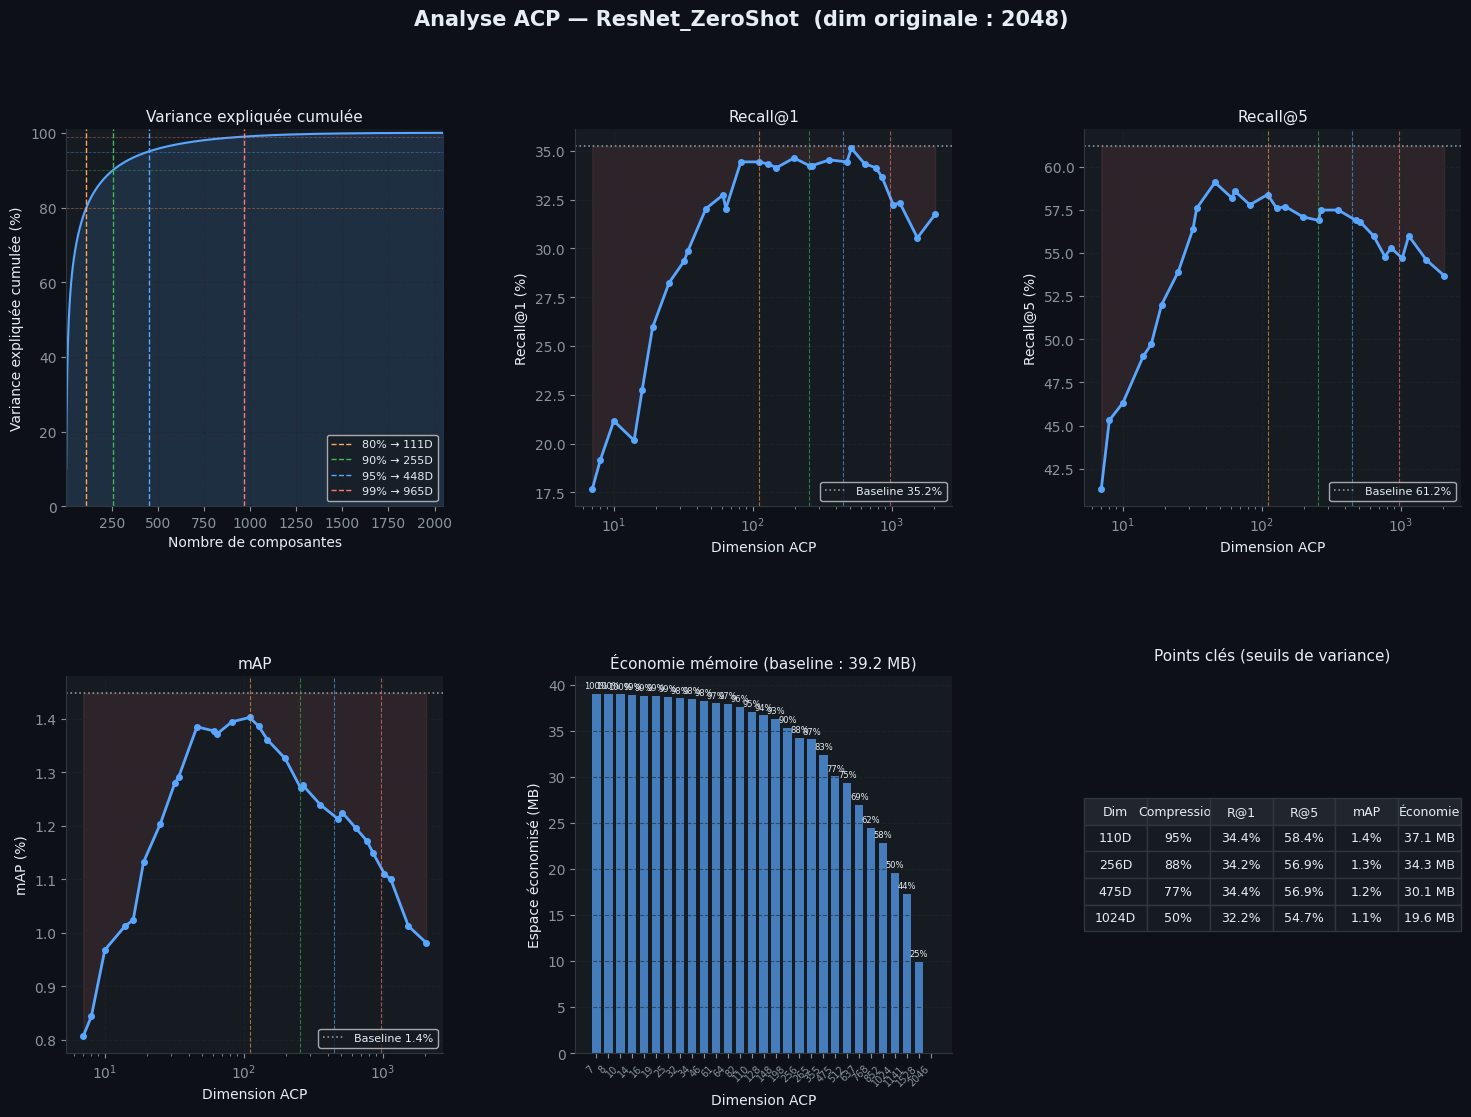

In [28]:
def plot_model_analysis(model_name, result, recall_ks):
    color   = MODEL_COLORS.get(model_name, "#58a6ff")
    res     = result["pca_results"]
    dims    = [r["dim"] for r in res]
    cumvar  = result["cumvar"]
    thresh  = result["thresholds"]
    orig_d  = result["orig_dim"]
    orig_mb = result["orig_mb"]
    base    = result["baseline"]

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Analyse ACP — {model_name}  (dim originale : {orig_d})",
                 fontsize=15, fontweight="bold", color="#e6edf3", y=0.98)

    gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    ax_var  = fig.add_subplot(gs[0, 0])
    ax_r1   = fig.add_subplot(gs[0, 1])
    ax_r5   = fig.add_subplot(gs[0, 2])
    ax_map  = fig.add_subplot(gs[1, 0])
    ax_mem  = fig.add_subplot(gs[1, 1])
    ax_comp = fig.add_subplot(gs[1, 2])  # tableau récapitulatif

    comps = np.arange(1, len(cumvar) + 1)

    # ── A. Variance expliquée cumulée
    ax_var.plot(comps, cumvar * 100, color=color, linewidth=1.5)
    ax_var.fill_between(comps, cumvar * 100, alpha=0.15, color=color)
    thresh_styles = {0.80: ("--", "#ffa657"), 0.90: ("--", "#3fb950"),
                     0.95: ("--", "#58a6ff"), 0.99: ("--", "#ff7b72")}
    for t, (ls, tc) in thresh_styles.items():
        d = thresh[t]
        ax_var.axvline(d, linestyle=ls, color=tc, linewidth=1,
                       label=f"{int(t*100)}% → {d}D")
        ax_var.axhline(t * 100, linestyle=ls, color=tc, linewidth=0.6, alpha=0.4)
    ax_var.set_xlabel("Nombre de composantes")
    ax_var.set_ylabel("Variance expliquée cumulée (%)")
    ax_var.set_title("Variance expliquée cumulée", fontsize=11)
    ax_var.legend(fontsize=8, loc="lower right")
    ax_var.grid(True)
    ax_var.set_ylim(0, 101)
    ax_var.set_xlim(1, len(cumvar))

    # ── B, C. Recall@K
    for ax, k in zip([ax_r1, ax_r5], recall_ks[:2]):
        vals = [r[f"Recall@{k}"] * 100 for r in res]
        base_val = base[f"Recall@{k}"] * 100
        ax.plot(dims, vals, color=color, marker="o", markersize=4)
        ax.axhline(base_val, linestyle=":", color="#8b949e", linewidth=1.2,
                   label=f"Baseline {base_val:.1f}%")
        ax.fill_between(dims, vals, base_val, where=[v >= base_val for v in vals],
                        alpha=0.1, color="#3fb950")
        ax.fill_between(dims, vals, base_val, where=[v < base_val for v in vals],
                        alpha=0.1, color="#ff7b72")
        # Seuils de variance verticaux
        for t, (ls, tc) in thresh_styles.items():
            ax.axvline(thresh[t], linestyle=ls, color=tc, linewidth=0.8, alpha=0.6)
        ax.set_xlabel("Dimension ACP")
        ax.set_ylabel(f"Recall@{k} (%)")
        ax.set_title(f"Recall@{k}", fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(True)
        ax.set_xscale("log")

    # ── D. mAP
    map_vals  = [r["mAP"] * 100 for r in res]
    base_map  = base["mAP"] * 100
    ax_map.plot(dims, map_vals, color=color, marker="o", markersize=4)
    ax_map.axhline(base_map, linestyle=":", color="#8b949e", linewidth=1.2,
                   label=f"Baseline {base_map:.1f}%")
    ax_map.fill_between(dims, map_vals, base_map,
                        where=[v >= base_map for v in map_vals], alpha=0.1, color="#3fb950")
    ax_map.fill_between(dims, map_vals, base_map,
                        where=[v < base_map for v in map_vals], alpha=0.1, color="#ff7b72")
    for t, (ls, tc) in thresh_styles.items():
        ax_map.axvline(thresh[t], linestyle=ls, color=tc, linewidth=0.8, alpha=0.6)
    ax_map.set_xlabel("Dimension ACP")
    ax_map.set_ylabel("mAP (%)")
    ax_map.set_title("mAP", fontsize=11)
    ax_map.legend(fontsize=8)
    ax_map.grid(True)
    ax_map.set_xscale("log")

    # ── E. Compression mémoire
    mem_vals   = [r["mem_mb"] for r in res]
    savings    = [orig_mb - m for m in mem_vals]
    ax_mem.bar(range(len(dims)), savings, color=color, alpha=0.7, width=0.7)
    ax_mem.set_xticks(range(len(dims)))
    ax_mem.set_xticklabels([str(d) for d in dims], rotation=45, ha="right", fontsize=7)
    ax_mem.set_xlabel("Dimension ACP")
    ax_mem.set_ylabel("Espace économisé (MB)")
    ax_mem.set_title(f"Économie mémoire (baseline : {orig_mb:.1f} MB)", fontsize=11)
    ax_mem.grid(True, axis="y")
    # Annotation pourcentage sur chaque barre
    for i, (s, m) in enumerate(zip(savings, mem_vals)):
        pct = s / orig_mb * 100
        if pct > 10:  # n'affiche que si lisible
            ax_mem.text(i, s + orig_mb * 0.01, f"{pct:.0f}%",
                        ha="center", va="bottom", fontsize=6, color="#e6edf3")

    # ── F. Tableau récapitulatif — points clés
    ax_comp.axis("off")
    key_dims = sorted(set([thresh[0.80], thresh[0.90], thresh[0.95], thresh[0.99]]))

    rows = []
    for d in key_dims:
        match = next((r for r in res if r["dim"] == d), None)
        if match is None:
            # Prend le plus proche
            match = min(res, key=lambda r: abs(r["dim"] - d))
        rows.append([
            f"{match['dim']}D",
            f"{match['compression']:.0f}%",
            f"{match.get('Recall@1', 0)*100:.1f}%",
            f"{match.get('Recall@5', 0)*100:.1f}%",
            f"{match['mAP']*100:.1f}%",
            f"{orig_mb - match['mem_mb']:.1f} MB",
        ])

    col_labels = ["Dim", "Compression", "R@1", "R@5", "mAP", "Économie"]
    tbl = ax_comp.table(
        cellText=rows, colLabels=col_labels,
        loc="center", cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#161b22" if r > 0 else "#21262d")
        cell.set_edgecolor("#30363d")
        cell.set_text_props(color="#e6edf3")
    ax_comp.set_title("Points clés (seuils de variance)", fontsize=11, pad=12)

    plt.savefig(f"{SAVE_DIR}/pca_analysis_{model_name}.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Sauvegardé : pca_analysis_{model_name}.png")


# ── Génération des graphes
for model_name, result in all_results.items():
    plot_model_analysis(model_name, result, RECALL_K_VALUES)

---
## 🏆 Comparaison globale — tous les modèles

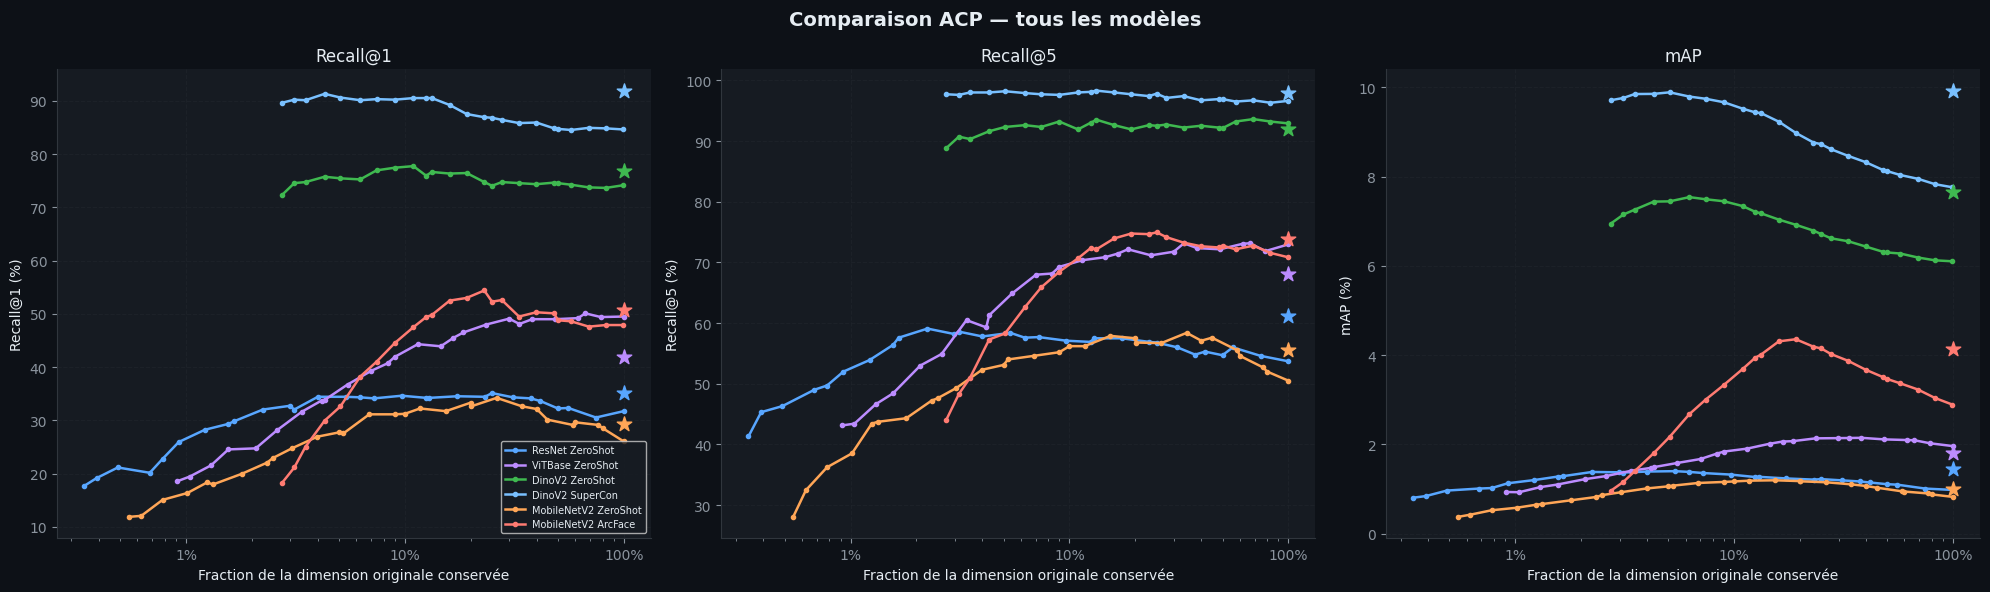

Sauvegardé : pca_comparison_all_models.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Comparaison ACP — tous les modèles", fontsize=14,
             fontweight="bold", color="#e6edf3")

metrics_to_plot = ["Recall@1", "Recall@5", "mAP"]

for ax, metric in zip(axes, metrics_to_plot):
    for model_name, result in all_results.items():
        color = MODEL_COLORS.get(model_name, "#58a6ff")
        res   = result["pca_results"]
        dims  = [r["dim"] for r in res]
        vals  = [r.get(metric, r.get("mAP", 0)) * 100 for r in res]
        if metric == "mAP":
            vals = [r["mAP"] * 100 for r in res]

        orig_dim  = result["orig_dim"]
        base_val  = result["baseline"].get(metric, result["baseline"].get("mAP", 0)) * 100

        # Normalise l'axe x en fraction de la dim originale
        fracs = [d / orig_dim for d in dims]
        ax.plot(fracs, vals, color=color, marker="o", markersize=3,
                label=model_name.replace("_", " "), linewidth=1.8)
        ax.scatter([1.0], [base_val], color=color, marker="*", s=120, zorder=5)

    ax.set_xlabel("Fraction de la dimension originale conservée")
    ax.set_ylabel(f"{metric} (%)")
    ax.set_title(metric, fontsize=12)
    ax.grid(True)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

axes[0].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pca_comparison_all_models.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Sauvegardé : pca_comparison_all_models.png")

---
## 💾 Gain mémoire global

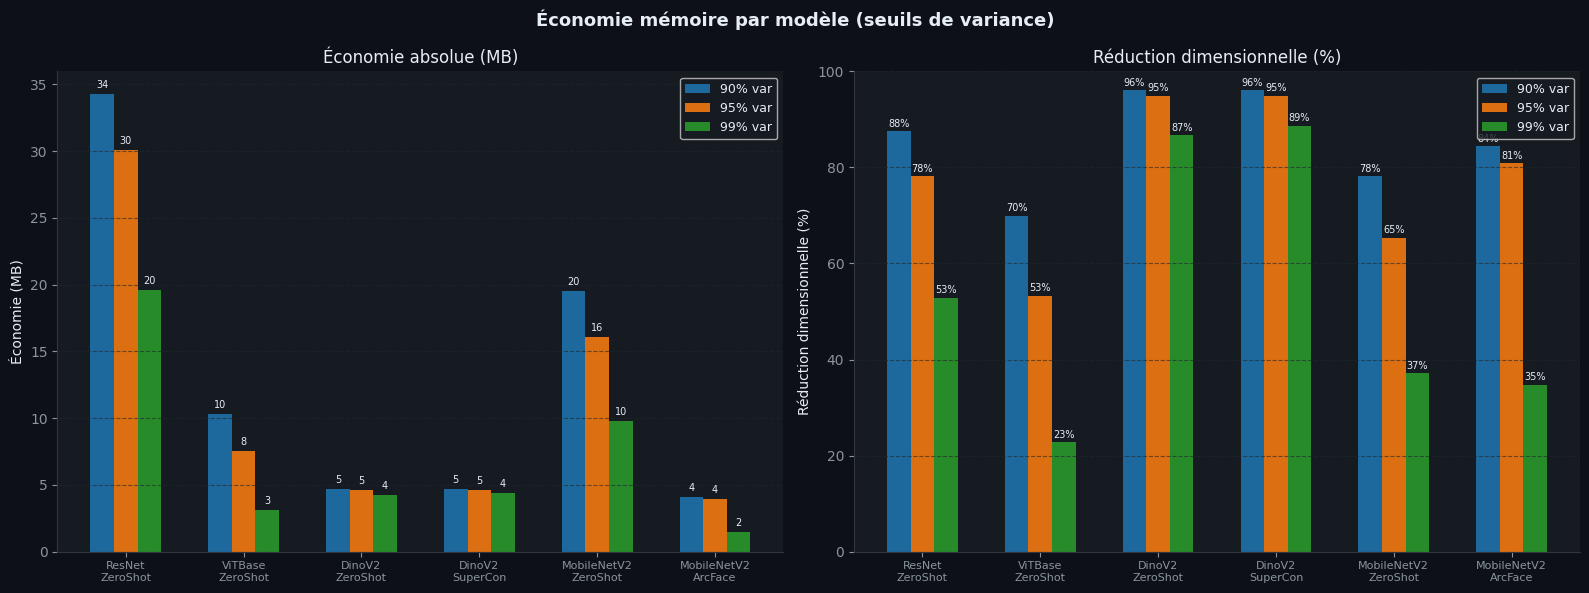

Sauvegardé : pca_memory_savings.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Économie mémoire par modèle (seuils de variance)",
             fontsize=13, fontweight="bold", color="#e6edf3")

# ── Gauche : espace absolu économisé par seuil
ax = axes[0]
variance_targets = [0.90, 0.95, 0.99]
bar_width  = 0.2
model_list = list(all_results.keys())
x = np.arange(len(model_list))

for i, vt in enumerate(variance_targets):
    savings = []
    for mname in model_list:
        r    = all_results[mname]
        d    = r["thresholds"][vt]
        match = min(r["pca_results"], key=lambda x: abs(x["dim"] - d))
        savings.append(r["orig_mb"] - match["mem_mb"])
    offset = (i - 1) * bar_width
    bars = ax.bar(x + offset, savings, bar_width, label=f"{int(vt*100)}% var",
                  alpha=0.85)
    for bar, s in zip(bars, savings):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{s:.0f}", ha="center", va="bottom", fontsize=7, color="#e6edf3")

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in model_list], fontsize=8)
ax.set_ylabel("Économie (MB)")
ax.set_title("Économie absolue (MB)")
ax.legend(fontsize=9)
ax.grid(True, axis="y")

# ── Droite : % compression
ax2 = axes[1]
for i, vt in enumerate(variance_targets):
    pcts = []
    for mname in model_list:
        r = all_results[mname]
        d = r["thresholds"][vt]
        pcts.append((1 - d / r["orig_dim"]) * 100)
    offset = (i - 1) * bar_width
    bars = ax2.bar(x + offset, pcts, bar_width, label=f"{int(vt*100)}% var", alpha=0.85)
    for bar, p in zip(bars, pcts):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{p:.0f}%", ha="center", va="bottom", fontsize=7, color="#e6edf3")

ax2.set_xticks(x)
ax2.set_xticklabels([m.replace("_", "\n") for m in model_list], fontsize=8)
ax2.set_ylabel("Réduction dimensionnelle (%)")
ax2.set_title("Réduction dimensionnelle (%)")
ax2.legend(fontsize=9)
ax2.grid(True, axis="y")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/pca_memory_savings.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Sauvegardé : pca_memory_savings.png")

---
## 📋 Tableau récapitulatif final

In [37]:
import pandas as pd

rows = []
for mname, result in all_results.items():
    base = result["baseline"]
    orig_dim = result["orig_dim"]
    orig_mb  = result["orig_mb"]

    for vt in [0.90, 0.95, 0.99]:
        d = result["thresholds"][vt]
        match = min(result["pca_results"], key=lambda r: abs(r["dim"] - d))
        row = {
            "Modèle":             mname,
            "Variance cible":     f"{int(vt*100)}%",
            "Dim originale":      orig_dim,
            "Dim ACP":            match["dim"],
            "Compression (%)":    f"{match['compression']:.0f}%",
            "Taille orig (MB)":   f"{orig_mb:.1f}",
            "Taille ACP (MB)":    f"{match['mem_mb']:.1f}",
            "Économie (MB)":      f"{orig_mb - match['mem_mb']:.1f}",
            "Baseline R@1":       f"{base.get('Recall@1',0)*100:.1f}%",
            "ACP R@1":            f"{match.get('Recall@1',0)*100:.1f}%",
            "Baseline mAP":       f"{base['mAP']*100:.1f}%",
            "ACP mAP":            f"{match['mAP']*100:.1f}%",
            "ΔmAP":               f"{(match['mAP'] - base['mAP'])*100:+.1f}%",
        }
        rows.append(row)

df = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(df.to_string(index=False))

# Export CSV
df.to_csv(f"{SAVE_DIR}/pca_summary.csv", index=False)
print("\n✅ Résumé exporté : pca_summary.csv")

              Modèle Variance cible  Dim originale  Dim ACP Compression (%) Taille orig (MB) Taille ACP (MB) Économie (MB) Baseline R@1 ACP R@1 Baseline mAP ACP mAP  ΔmAP
     ResNet_ZeroShot            90%           2048      256             88%             39.2             4.9          34.3        35.2%   34.2%         1.4%    1.3% -0.2%
     ResNet_ZeroShot            95%           2048      475             77%             39.2             9.1          30.1        35.2%   34.4%         1.4%    1.2% -0.2%
     ResNet_ZeroShot            99%           2048     1024             50%             39.2            19.6          19.6        35.2%   32.2%         1.4%    1.1% -0.3%
    ViTBase_ZeroShot            90%            768      230             70%             14.7             4.4          10.3        41.8%   49.1%         1.8%    2.1% +0.3%
    ViTBase_ZeroShot            95%            768      373             51%             14.7             7.1           7.6        41.8%   49.0%  

---
## 💡 Recommandation automatique par modèle

Choisit la dimension ACP qui maximise le score combiné `mAP × (1 - compression_pénalité)` avec une légère préférence pour la compression.

In [42]:
import json

print("\n" + "═" * 70)
print("  RECOMMANDATIONS AUTOMATIQUES")
print("═" * 70)

recommendations = {}

for mname, result in all_results.items():
    base_map  = result["baseline"]["mAP"]
    orig_dim  = result["orig_dim"]
    orig_mb   = result["orig_mb"]

    best = max(
        result["pca_results"],
        key=lambda r: (r["mAP"] / max(base_map, 1e-6)) * np.sqrt(r["compression"] / 100 + 0.01)
    )

    delta_map = (best["mAP"] - base_map) * 100

    recommendations[mname] = {
        "dim_originale":       orig_dim,
        "dim_recommandee":     best["dim"],
        "compression_pct":     round(best["compression"], 1),
        "memoire_orig_mb":     round(orig_mb, 2),
        "memoire_acp_mb":      round(best["mem_mb"], 2),
        "memoire_economie_mb": round(orig_mb - best["mem_mb"], 2),
        "baseline_mAP":        round(base_map * 100, 2),
        "acp_mAP":             round(best["mAP"] * 100, 2),
        "delta_mAP":           round(delta_map, 2),
        "baseline_recall":     {k: round(result["baseline"].get(k, 0) * 100, 2)
                                 for k in result["baseline"] if k.startswith("Recall")},
        "acp_recall":          {k: round(best.get(k, 0) * 100, 2)
                                 for k in best if k.startswith("Recall")},
    }

    print(f"\n  {mname}")
    print(f"    → Dimension recommandée : {best['dim']}D  "
          f"(depuis {orig_dim}D, {best['compression']:.0f}% de réduction)")
    print(f"    → mAP : {base_map*100:.1f}% → {best['mAP']*100:.1f}%  (Δ {delta_map:+.1f}%)")
    print(f"    → Mémoire : {orig_mb:.1f} MB → {best['mem_mb']:.1f} MB  "
          f"(économie {orig_mb - best['mem_mb']:.1f} MB)")

print("\n" + "═" * 70)
# ── Export JSON
def to_python(obj):
    """Convertit récursivement les types numpy en types Python natifs."""
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

output_path = f"{SAVE_DIR}/pca_recommendations.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(to_python(recommendations), f, indent=2, ensure_ascii=False)

print(f"\n✅ Recommandations exportées : {output_path}")


══════════════════════════════════════════════════════════════════════
  RECOMMANDATIONS AUTOMATIQUES
══════════════════════════════════════════════════════════════════════

  ResNet_ZeroShot
    → Dimension recommandée : 46D  (depuis 2048D, 98% de réduction)
    → mAP : 1.4% → 1.4%  (Δ -0.1%)
    → Mémoire : 39.2 MB → 0.9 MB  (économie 38.3 MB)

  ViTBase_ZeroShot
    → Dimension recommandée : 128D  (depuis 768D, 83% de réduction)
    → mAP : 1.8% → 2.1%  (Δ +0.3%)
    → Mémoire : 14.7 MB → 2.4 MB  (économie 12.2 MB)

  DinoV2_ZeroShot
    → Dimension recommandée : 16D  (depuis 256D, 94% de réduction)
    → mAP : 7.7% → 7.5%  (Δ -0.1%)
    → Mémoire : 4.9 MB → 0.3 MB  (économie 4.6 MB)

  DinoV2_SuperCon
    → Dimension recommandée : 9D  (depuis 256D, 96% de réduction)
    → mAP : 9.9% → 9.8%  (Δ -0.1%)
    → Mémoire : 4.9 MB → 0.2 MB  (économie 4.7 MB)

  MobileNetV2_ZeroShot
    → Dimension recommandée : 150D  (depuis 1280D, 88% de réduction)
    → mAP : 1.0% → 1.2%  (Δ +0.2%)
    